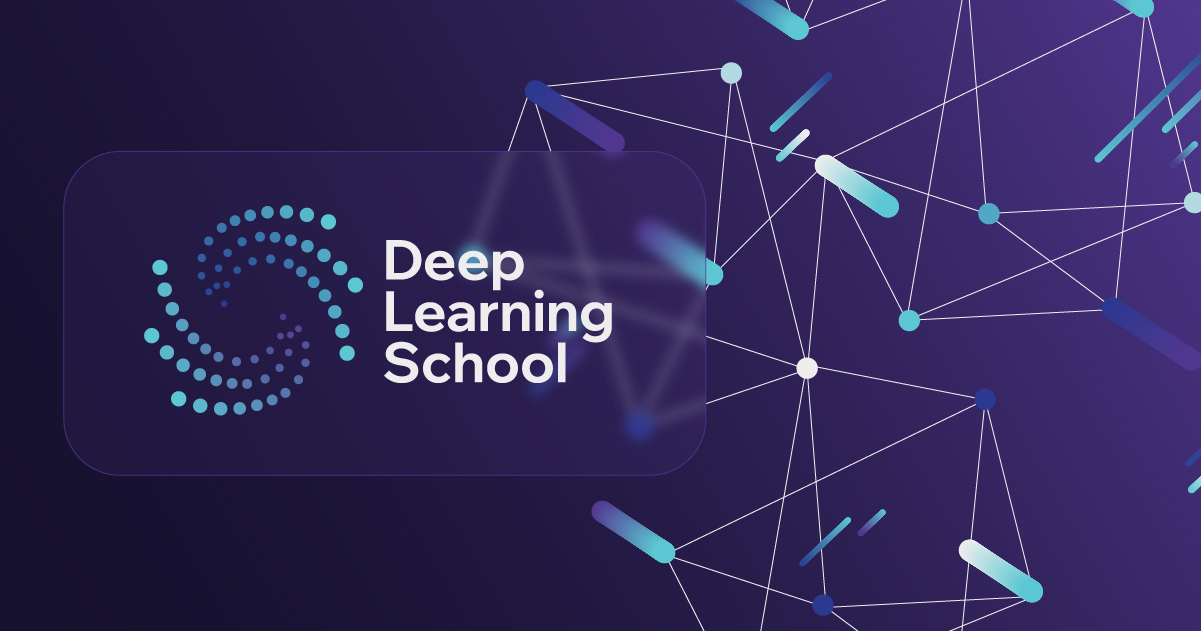


<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Классификация изображений</b></h3>


# Домашнее задание. Классификация изображений

Сегодня вам предстоить помочь телекомпании FOX в обработке их контента. Как вы знаете, сериал "Симпсоны" идет на телеэкранах более 25 лет, и за это время скопилось очень много видеоматериала. Персоонажи менялись вместе с изменяющимися графическими технологиями, и Гомер Симпсон-2018 не очень похож на Гомера Симпсона-1989. В этом задании вам необходимо классифицировать персонажей, проживающих в Спрингфилде. Думаю, нет смысла представлять каждого из них в отдельности.



В нашем тесте будет 990 картнок, для которых вам будет необходимо предсказать класс.

### Установка зависимостей

In [1]:
# we will verify that GPU is enabled for this notebook
# following should print: CUDA is available!  Training on GPU ...
#
# if it prints otherwise, then you need to enable GPU:
# from Menu > Runtime > Change Runtime Type > Hardware Accelerator > GPU

import torch
import numpy as np

train_on_gpu = torch.cuda.is_available()

if not train_on_gpu:
    print('CUDA is not available.  Training on CPU ...')
else:
    print('CUDA is available!  Training on GPU ...')

CUDA is available!  Training on GPU ...


In [4]:
from google.colab import userdata
import os

"""
1) перейти в https://www.kaggle.com/settings далее в блоке API находим и кликаем кнопку "Create New Token", скачивается json с секретами
2) в колабе в разделе секретов (иконка с ключом в левом сайдбаре) добавляем KAGGLE_USERNAME и KAGGLE_KEY из json-а в пункте выше
"""

os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')
os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')

In [5]:
!kaggle competitions download -c journey-springfield   # скачивает данные в Colab

 98% 509M/521M [00:01<00:00, 339MB/s]
100% 521M/521M [00:03<00:00, 165MB/s]


In [6]:
!unzip journey-springfield.zip -d /content/dataset   # распаковка данных в дирректорию dataset в Colab

Выходные данные были обрезаны до нескольких последних строк (5000).
  inflating: /content/dataset/train/simpsons_dataset/moe_szyslak/pic_1025.jpg  
  inflating: /content/dataset/train/simpsons_dataset/moe_szyslak/pic_1026.jpg  
  inflating: /content/dataset/train/simpsons_dataset/moe_szyslak/pic_1027.jpg  
  inflating: /content/dataset/train/simpsons_dataset/moe_szyslak/pic_1028.jpg  
  inflating: /content/dataset/train/simpsons_dataset/moe_szyslak/pic_1029.jpg  
  inflating: /content/dataset/train/simpsons_dataset/moe_szyslak/pic_1030.jpg  
  inflating: /content/dataset/train/simpsons_dataset/moe_szyslak/pic_1031.jpg  
  inflating: /content/dataset/train/simpsons_dataset/moe_szyslak/pic_1032.jpg  
  inflating: /content/dataset/train/simpsons_dataset/moe_szyslak/pic_1033.jpg  
  inflating: /content/dataset/train/simpsons_dataset/moe_szyslak/pic_1034.jpg  
  inflating: /content/dataset/train/simpsons_dataset/moe_szyslak/pic_1035.jpg  
  inflating: /content/dataset/train/simpsons_dataset

In [7]:
!nvidia-smi
import torch
torch.cuda.is_available()

Fri Jul 11 14:23:04 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8              9W /   70W |       2MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

True

In [8]:
import pickle
import numpy as np
from skimage import io
import shutil

from tqdm import tqdm, tqdm_notebook
from PIL import Image
from pathlib import Path

from torchvision import transforms
from multiprocessing.pool import ThreadPool
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

import cv2
import random

from matplotlib import colors, pyplot as plt
%matplotlib inline

# в sklearn не все гладко, чтобы в colab удобно выводить картинки
# мы будем игнорировать warnings
import warnings
warnings.filterwarnings(action='ignore', category=DeprecationWarning)

In [9]:
# это пакет для проверки версий других пакетов
import pkg_resources

In [10]:
!python --version

Python 3.11.13


In [11]:
for b in ['torch', 'torchvision', 'tqdm', 'matplotlib', 'seaborn', 'Pillow']:
    print(b + ' version: '+ pkg_resources.get_distribution(b).version)

torch version: 2.6.0+cu124
torchvision version: 0.21.0+cu124
tqdm version: 4.67.1
matplotlib version: 3.10.0
seaborn version: 0.13.2
Pillow version: 11.2.1


#### Версии питона и библиотек, на которых работал эталонный ноутбук:

Python 3.11.11

torch version: 2.5.1+cu124

torchvision version: 0.20.1+cu124

tqdm version: 4.67.1

matplotlib version: 3.10.0

seaborn version: 0.13.2

Pillow version: 11.1.0


In [12]:
# разные режимы датасета
DATA_MODES = ['train', 'val', 'test']
# все изображения будут масштабированы к размеру 224x224 px
RESCALE_SIZE = 224
# работаем на видеокарте
DEVICE = torch.device("cuda")

Полезная статья, которой мы вдохновились при создании класса `SimpsonsDataset`:

https://jhui.github.io/2018/02/09/PyTorch-Data-loading-preprocess_torchvision/

Ниже мы исспользуем враппер над датасетом для удобной работы. Вам стоит понимать, что происходит с LabelEncoder и  с torch.Transformation.

`ToTensor` конвертирует  `PIL Image` с параметрами в диапазоне $[0, 255]$ (как все пиксели) в `FloatTensor` размера ($C \times H \times W$) $[0,1]$ , затем производится масштабирование:
$\text{input} = \frac{\text{input} - \mu}{\text{standard deviation}} $, <br>       константы - средние и дисперсии по каналам на основе ImageNet


Стоит также отметить, что мы переопределяем метод __getitem__ для удобства работы с данной структурой данных.
 Также используется LabelEncoder для преобразования строковых меток классов в id и обратно. В описании датасета указано, что картинки разного размера, так как брались напрямую с видео, поэтому следуем привести их к одному размеру (это делает метод  _prepare_sample).

In [13]:
class SimpsonsDataset(Dataset):
    """
    Датасет с картинками, который паралельно подгружает их из папок
    производит скалирование и превращение в торчевые тензоры
    """
    def __init__(self, files, mode):
        super().__init__()
        # список файлов для загрузки
        self.files = sorted(files)
        # режим работы
        self.mode = mode

        if self.mode not in DATA_MODES:
            print(f"{self.mode} is not correct; correct modes: {DATA_MODES}")
            raise NameError

        self.len_ = len(self.files)

        self.label_encoder = LabelEncoder()

        if self.mode != 'test':
            self.labels = [path.parent.name for path in self.files]
            self.label_encoder.fit(self.labels)

            with open('label_encoder.pkl', 'wb') as le_dump_file:
                  pickle.dump(self.label_encoder, le_dump_file)

    def __len__(self):
        return self.len_

    def load_sample(self, file):
        image = Image.open(file)
        image.load()
        return image

    def __getitem__(self, index):
        # для преобразования изображений в тензоры PyTorch и нормализации входа
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
        x = self.load_sample(self.files[index])
        x = self._prepare_sample(x)
        x = np.array(x / 255, dtype='float32')
        x = transform(x)
        if self.mode == 'test':
            return x
        else:
            label = self.labels[index]
            label_id = self.label_encoder.transform([label])
            y = label_id.item()
            return x, y

    def _prepare_sample(self, image):
        image = image.resize((RESCALE_SIZE, RESCALE_SIZE))
        return np.array(image)

In [14]:
def imshow(inp, title=None, plt_ax=plt, default=False):
    """Imshow для тензоров"""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt_ax.imshow(inp)
    if title is not None:
        plt_ax.set_title(title)
    plt_ax.grid(False)

In [15]:
#определим директории с тренировочными и тестовыми файлами
TRAIN_DIR = Path('./dataset/train/simpsons_dataset')
TEST_DIR = Path('./dataset/testset/testset')

/tmp/ipython-input-16-654063179.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


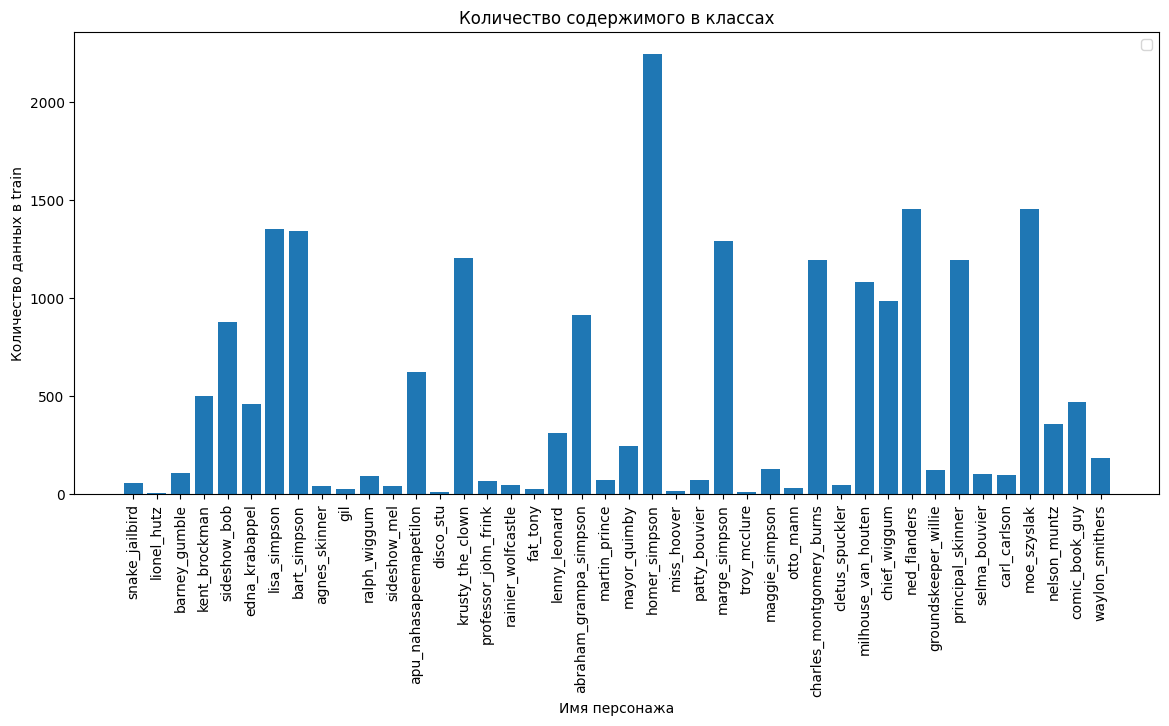

In [16]:
def find_count_data_folders(dir, verbose=False):
    count_data_folders = {}
    names = []
    counts = []
    for folder in os.listdir(dir):
        full_path_folder = os.path.join(dir, folder)
        count_ = len(os.listdir(full_path_folder))

        count_data_folders[folder] = count_
        names.append(folder)
        counts.append(count_)

    plt.figure(figsize=(14, 6))
    plt.xticks(rotation=90)
    plt.bar(names, counts)
    plt.xlabel('Имя персонажа')
    plt.ylabel('Количество данных в train')
    plt.title('Количество содержимого в классах')
    plt.legend()
    plt.show()

    return count_data_folders

count_data_folders = find_count_data_folders(dir=TRAIN_DIR)

In [17]:
def save_data(img, base_name, suffix, folder_path):
    """Сохраняет изображение с заданным суффиксом"""
    cv2.imwrite(os.path.join(folder_path, f"{base_name}_{suffix}.jpg"), img)


def rotate_image_by_a(img, a):
    """Поворот изображения на угол `a` градусов"""
    (h, w) = img.shape[:2]
    center = (w // 2, h // 2)
    angle = a
    scale = 1.0  # Масштаб (1.0 = без изменения размера)
    rotation_matrix = cv2.getRotationMatrix2D(center, angle, scale)  # Матрица поворота
    rotated = cv2.warpAffine(img, rotation_matrix, (w, h), borderMode=cv2.BORDER_CONSTANT, borderValue=(0, 0, 0))
    return rotated


def add_gaussian_noise(image, sigma=25):
    """Добавляет гауссовский шум"""
    noise = np.random.normal(0, sigma, image.shape).astype(np.uint8)
    noisy_image = cv2.add(image, noise)
    return np.clip(noisy_image, 0, 255)  # Обрезка значений до [0, 255]


def adjust_saturation(img, factor=1.5):
    """Изменение насыщенности (HSV)"""
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    hsv[..., 1] = np.clip(hsv[..., 1] * factor, 0, 255)
    return cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)


def aug_image(img, base_name, folder_path, count_data):
    """Применяет аугментацию и сохраняет результат"""

    save_data(img, base_name, "original", folder_path) # сохраняем оригинал

    v_flipped_img = cv2.flip(img, 1)   # горизонтальное отражение
    save_data(v_flipped_img, base_name, "h", folder_path)

    rotate_img = rotate_image_by_a(img, 30)   # поворот на угол 30
    save_data(rotate_img, base_name, "rt_30", folder_path)

    if count_data <= 200:
        for angle in [5, -5, -30, 45, -45, 60, -60]:
            rotate_img = rotate_image_by_a(img, angle)
            save_data(rotate_img, base_name, f"rt_{angle}", folder_path)

        if count_data <= 100:
            # изменение яркости
            brightness = 0.2
            brightness = random.uniform(1 - brightness, 1 + brightness)
            bright_img = cv2.convertScaleAbs(img, alpha=1.0, beta=(brightness-1)*128)
            save_data(bright_img, base_name, "brig", folder_path)

            # изменение контраста
            contrast = 0.2
            contrast = random.uniform(1 - contrast, 1 + contrast)
            contrast_img = cv2.convertScaleAbs(img, alpha=contrast, beta=0)
            save_data(contrast_img, base_name, "contr", folder_path)

            noisy_img = add_gaussian_noise(img)
            save_data(noisy_img, base_name, "noisy", folder_path)

In [18]:
def fill_to_min_count(folder_path, min_count=500):
    """Дополняет папку до `min_count` изображений, если их меньше"""
    existing_files = os.listdir(folder_path)
    current_count = len(existing_files)

    if current_count >= min_count:
        return  # Всё в порядке, дополнять не нужно

    # Если файлов мало, дополняем их:
    needed = min_count - current_count
    print(f"Дополняем папку {folder_path} на {needed} изображений...")

    # Выбираем случайные исходные изображения для аугментации
    source_files = random.choices(existing_files, k=needed)

    for i, file in enumerate(source_files):
        img_path = os.path.join(folder_path, file)
        img = cv2.imread(img_path)

        if img is None:
            continue  # Пропускаем битые файлы

        # Генерируем уникальный суффикс для новой аугментации
        new_suffix = f"fill_{i}"

        # Применяем случайную аугментацию
        aug_type = random.choice(["rotate", "noise", "brightness"])

        if aug_type == "rotate":
            angle = random.randint(-45, 45)
            aug_img = rotate_image_by_a(img, angle)
        elif aug_type == "noise":
            aug_img = add_gaussian_noise(img, sigma=random.randint(10, 30))
        else:  # brightness
            brightness = random.uniform(0.9, 1.2)
            aug_img = cv2.convertScaleAbs(img, alpha=1.0, beta=(brightness-1)*128)

        # Сохраняем новую аугментированную версию
        base_name = os.path.splitext(img_name)[0]
        save_data(aug_img, base_name, new_suffix, folder_path)

In [19]:
output_train_dir = './dataset/train/aug_simpsons_dataset/'
os.makedirs(output_train_dir, exist_ok=True)  # Создаём папку, если её нет

In [20]:
for folder, count_data in count_data_folders.items():
    cur_folder_path = os.path.join(TRAIN_DIR, folder)
    res_folder_path = os.path.join(output_train_dir, folder)

    if count_data <= 500:
        os.makedirs(res_folder_path, exist_ok=True)  # Создаём папку, если её нет
        for img_name in os.listdir(cur_folder_path):
            img_path = os.path.join(cur_folder_path, img_name)

            img = cv2.imread(img_path)
            if img is None:  # если изображение битое
                print(f"Ошибка загрузки: {img_path}")
                continue  # Переходим к следующему изображению

            # Извлекаем имя файла без расширения
            base_name = os.path.splitext(img_name)[0]

            # Аугментируем и сохраняем
            aug_image(img, base_name, res_folder_path, count_data)
        fill_to_min_count(res_folder_path)  # проверяем количество данных, если мало - дополняем
    else:
        shutil.copytree(cur_folder_path, res_folder_path)

Дополняем папку ./dataset/train/aug_simpsons_dataset/lionel_hutz на 461 изображений...
Дополняем папку ./dataset/train/aug_simpsons_dataset/gil на 149 изображений...
Дополняем папку ./dataset/train/aug_simpsons_dataset/disco_stu на 396 изображений...
Дополняем папку ./dataset/train/aug_simpsons_dataset/fat_tony на 149 изображений...
Дополняем папку ./dataset/train/aug_simpsons_dataset/miss_hoover на 279 изображений...
Дополняем папку ./dataset/train/aug_simpsons_dataset/troy_mcclure на 396 изображений...
Дополняем папку ./dataset/train/aug_simpsons_dataset/otto_mann на 84 изображений...


In [ ]:
# !rm -rf ./drive/MyDrive/dataset/train/aug_simpsons_dataset/

/tmp/ipython-input-16-654063179.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


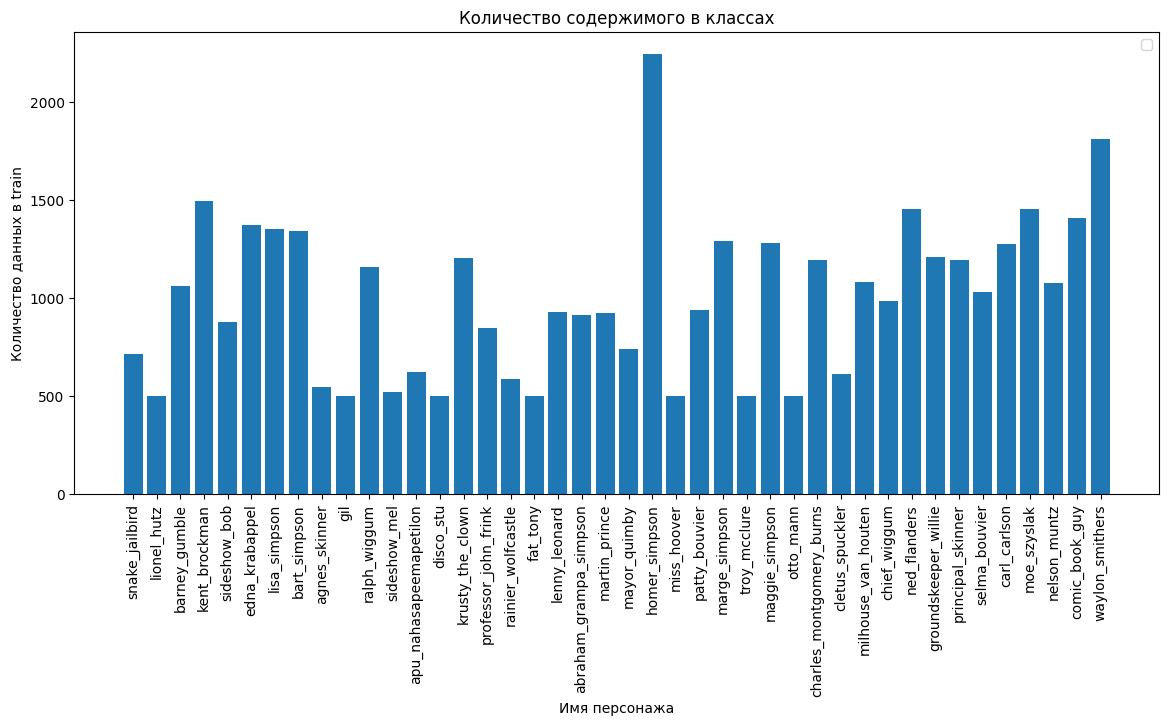

In [21]:
# посмотрим сколько теперь данных после аугментации
new_count_data_folders = find_count_data_folders(dir=output_train_dir)

In [22]:
new_TRAIN_DIR = Path(output_train_dir)
train_val_files = sorted(list(new_TRAIN_DIR.rglob('*.jpg')))
test_files = sorted(list(TEST_DIR.rglob('*.jpg')))

In [23]:
from sklearn.model_selection import train_test_split

train_val_labels = [path.parent.name for path in train_val_files]
train_files, val_files = train_test_split(train_val_files, test_size=0.25, \
                                          stratify=train_val_labels)

In [24]:
val_dataset = SimpsonsDataset(val_files, mode='val')

In [ ]:
# uncomment if you have problem with pillow
# def register_extension(id, extension): Image.EXTENSION[extension.lower()] = id.upper()
# Image.register_extension = register_extension
# def register_extensions(id, extensions):
#     for extension in extensions: register_extension(id, extension)
# Image.register_extensions = register_extensions

**!** Обратите внимание, что возможно, датасет требует дополнительной фильтрации, так как лейблы не всегда точно соответствуют картинкам.

Давайте посмотрим на наших героев внутри датасета.

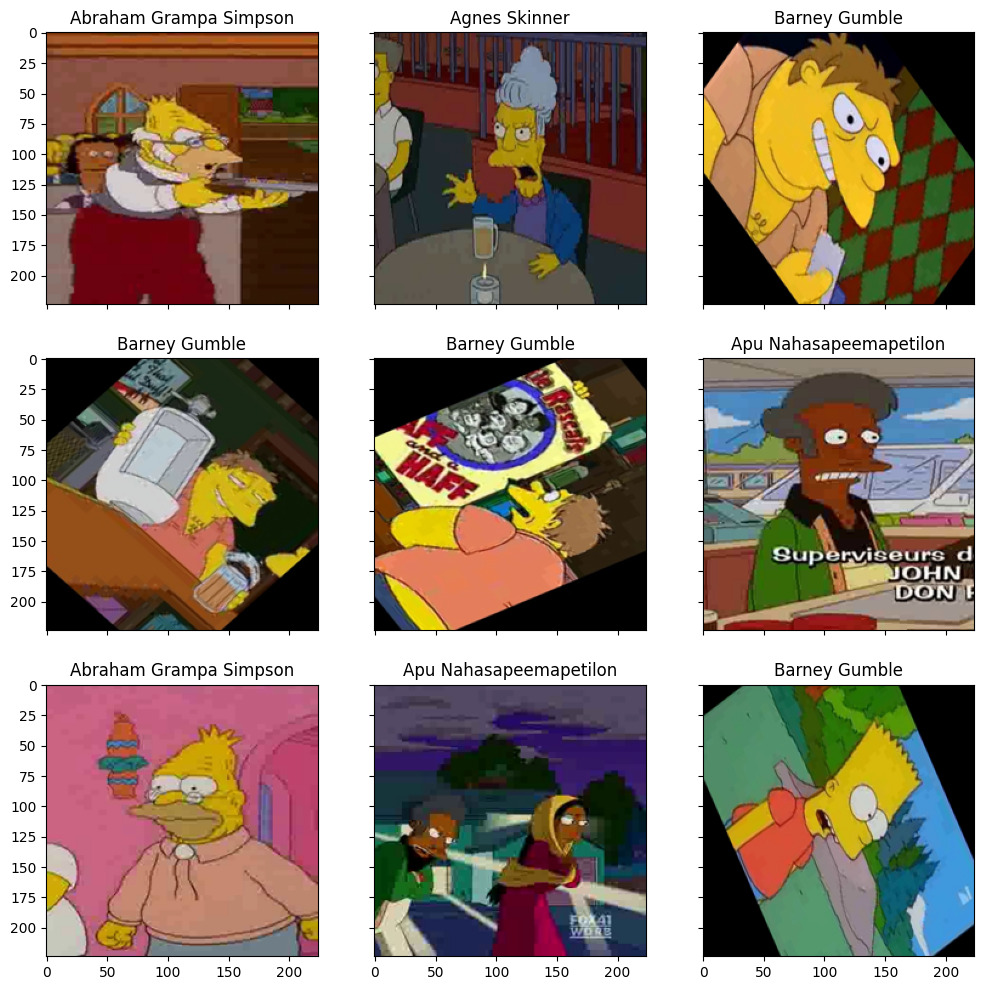

In [25]:
fig, ax = plt.subplots(nrows=3, ncols=3,figsize=(12, 12), \
                        sharey=True, sharex=True)
for fig_x in ax.flatten():
    random_characters = int(np.random.uniform(0,1000))
    im_val, label = val_dataset[random_characters]
    img_label = " ".join(map(lambda x: x.capitalize(),\
                val_dataset.label_encoder.inverse_transform([label])[0].split('_')))
    imshow(im_val.data.cpu(), \
          title=img_label,plt_ax=fig_x)

Можете добавить ваши любимые сцены и классифицировать их. (веселые результаты можно кидать в чат)

### Построение нейросети

<!-- Здесь вам предлагается дописать сверточную сеть глубины 4/5.  -->


О том, как работают свёртки подробней можно прочитать в документации Pytorch на функцию `Conv2d`:

https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html

Калькулятор свёрток:

https://madebyollin.github.io/convnet-calculator/

#### Модель

In [26]:
class SimpleCnn(nn.Module):
    """
    Очень простая сверточная нейронная сеть для классификации изображений.

    Эта сеть состоит из пяти сверточных слоев, каждый из которых
    включает в себя операцию свертки, функцию активации ReLU и операцию
    пулинга (max-pooling). На выходе используется полносвязный слой
    для классификации на заданное количество классов.

    Параметры:
    ----------
    n_classes : int
        Количество классов для классификации.

    Примечание:
    ----------
    Входные изображения должны иметь размерность (3, H, W), где
    3 - слои rgb для цветной картинки, а H и W - высота и ширина изображения,
    соответственно. Размер выходного тензора будет равен (n_classes).

    Методы:
    -------
    forward(x):
        Пропускает входные данные через сеть и возвращает логиты для
        каждого класса.
    """

    def __init__(self, n_classes):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3),
            nn.BatchNorm2d(8),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv4 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv5 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=96, kernel_size=3),
            nn.BatchNorm2d(96),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv6 = nn.Sequential(
            nn.Conv2d(in_channels=96, out_channels=128, kernel_size=3),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )


        self.out = nn.Linear(128, n_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)
        x = self.conv6(x)

        x = x.view(x.size(0), -1)
        logits = self.out(x)
        return logits

#### Функция обучения:

In [27]:
def fit_epoch(model, train_loader, criterion, optimizer):
    """
    Функция обучает модель на одной эпохе, используя предоставленный dataloader.

    Эта функция проходит по всем данным в `train_loader`, выполняет шаг моделью (forward),
    вычисляет лосс, выполняет обратное распространение с помощью заданного
    оптимизатора и обновляет веса модели.
    В конце эпохи возвращаются средний лосс и
    точность на обучающем наборе данных.

    Параметры:
    ----------
    model : nn.Module
        Модель, которую необходимо обучить. Должна быть экземпляром класса
        PyTorch `nn.Module`.

    train_loader : DataLoader
        Загрузчик данных, который предоставляет батчи входных данных и
        соответствующих меток. Должен возвращать кортежи (inputs, labels).

    criterion : nn.Module
        Функция потерь, используемая для вычисления ошибки между
        предсказаниями модели и истинными метками.

    optimizer : torch.optim.Optimizer
        Оптимизатор, используемый для обновления весов модели на основе
        градиентов, вычисленных в процессе обучения.

    Функция возвращает:
    ----------
    tuple
        Кортеж, содержащий средний лосс (train_loss) и точность (train_acc)
        на обучающем наборе данных за текущую эпоху.
    """

    running_loss = 0.0
    running_corrects = 0
    processed_data = 0

    for inputs, labels in train_loader:
        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE)
        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        preds = torch.argmax(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        processed_data += inputs.size(0)

    train_loss = running_loss / processed_data
    train_acc = running_corrects.cpu().numpy() / processed_data
    return train_loss, train_acc

#### Функция валидации:

In [28]:
def eval_epoch(model, val_loader, criterion):
    """
    Функция оценивает работу модели на валидационном наборе данных за одну эпоху.

    Эта функция проходит по всем данным в `val_loader`, выполняет прямое
    распространение, вычисляет лосс и точность модели. В конце эпохи
    возвращаются средний лосс и точность на валидационном наборе данных.

    Параметры:
    ----------
    model : nn.Module
        Модель, которую необходимо оценить. Должна быть экземпляром класса
        PyTorch `nn.Module`.

    val_loader : DataLoader
        Загрузчик данных, который предоставляет батчи входных данных и
        соответствующих меток для валидации. Должен возвращать кортежи
        (inputs, labels).

    criterion : nn.Module
        Функция потерь, используемая для вычисления ошибки между
        предсказаниями модели и истинными метками.

    Функция возвращает:
    ----------
    tuple
        Кортеж, содержащий среднюю потерю (val_loss) и точность (val_acc)
        на валидационном наборе данных за текущую эпоху.
    """
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    processed_size = 0

    for inputs, labels in val_loader:
        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE)

        with torch.set_grad_enabled(False):
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            preds = torch.argmax(outputs, 1)

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        processed_size += inputs.size(0)
    val_loss = running_loss / processed_size
    val_acc = running_corrects.double() / processed_size
    return val_loss, val_acc

#### Полный цикл обучения

заменил оптимизатор Adam на AdamW

добавил lr_scheduler.StepLR для оптимизации learning rate

In [29]:
def train(train_files, val_files, model, epochs, batch_size):
    """
    Функция обучает модель на обучающем наборе данных и оценивает ее на валидационном наборе данных.

    Эта функция создает загрузчики данных для обучающего и валидационного наборов,
    а затем выполняет обучение модели в течение заданного количества эпох.
    В конце каждой эпохи выводятся значения потерь и точности для обучающего и
    валидационного наборов. История обучения сохраняется и возвращается.

    Параметры:
    ----------
    train_files : list
        Список файлов или путей к файлам, содержащим обучающие данные.

    val_files : list
        Список файлов или путей к файлам, содержащим валидационные данные.

    model : nn.Module
        Модель, которую необходимо обучить. Должна быть экземпляром класса
        PyTorch `nn.Module`.

    epochs : int
        Количество эпох для обучения модели.

    batch_size : int
        Размер батча, используемый для загрузки данных.

    Возвращает:
    ----------
    list
        Список, содержащий кортежи (train_loss, train_acc, val_loss, val_acc)
        для каждой эпохи, где:
        - train_loss: средняя потеря на обучающем наборе.
        - train_acc: точность на обучающем наборе.
        - val_loss: средняя потеря на валидационном наборе.
        - val_acc: точность на валидационном наборе.
    """
    train_loader = DataLoader(train_files, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_files, batch_size=batch_size, shuffle=False)

    history = []
    log_template = "\nEpoch {ep:03d} train_loss: {t_loss:0.4f} \
    val_loss {v_loss:0.4f} train_acc {t_acc:0.4f} val_acc {v_acc:0.4f}"

    with tqdm(desc="epoch", total=epochs) as pbar_outer:
        opt = torch.optim.AdamW(model.parameters())
        scheduler = torch.optim.lr_scheduler.StepLR(opt, step_size=3, gamma=0.5)

        criterion = nn.CrossEntropyLoss()

        for epoch in range(epochs):
            train_loss, train_acc = fit_epoch(model, train_loader, criterion, opt)
            print("loss", train_loss)

            val_loss, val_acc = eval_epoch(model, val_loader, criterion)
            history.append((train_loss, train_acc, val_loss, val_acc))

            scheduler.step()
            pbar_outer.update(1)
            tqdm.write(log_template.format(ep=epoch+1, t_loss=train_loss,\
                                           v_loss=val_loss, t_acc=train_acc, v_acc=val_acc))

    return history

#### Применение модели к данным

In [30]:
def predict(model, test_loader):
    """
    Функция выполняет предсказание классов для тестового набора данных с использованием обученной модели.

    Эта функция принимает модель и загрузчик тестовых данных, применяет модель к
    изображениям и возвращает вероятности предсказанных классов.

    Параметры:
    ----------
    model : nn.Module
        Обученная модель, которая будет использоваться для предсказания.
        Должна быть экземпляром класса PyTorch `nn.Module`.

    test_loader : DataLoader
        Загрузчик данных, который предоставляет батчи входных данных для тестирования.
        Должен возвращать тензоры входных данных.

    Возвращает:
    ----------
    numpy.ndarray
        Массив вероятностей предсказанных классов для каждого примера в тестовом наборе.
        Размерность массива будет (N, C), где N - количество примеров, а C - количество классов.
    """

    with torch.no_grad():
        logits = []

        for inputs in test_loader:
            inputs = inputs.to(DEVICE)
            model.eval()
            outputs = model(inputs).cpu()
            logits.append(outputs)

    probs = nn.functional.softmax(torch.cat(logits), dim=-1).numpy()
    return probs

In [31]:
n_classes = len(np.unique(train_val_labels))
simple_cnn = SimpleCnn(n_classes).to(DEVICE)
print("we will classify : {}".format(n_classes))
print(simple_cnn)

we will classify : 42
SimpleCnn(
  (conv1): Sequential(
    (0): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv4): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, t

Запустим обучение сети.

In [32]:
if val_dataset is None:
    val_dataset = SimpsonsDataset(val_files, mode='val')

train_dataset = SimpsonsDataset(train_files, mode='train')

In [33]:
history = train(train_dataset, val_dataset, model=simple_cnn, epochs=10, batch_size=64)

epoch:   0%|          | 0/10 [00:00<?, ?it/s]

loss 1.799626565321345


epoch:  10%|█         | 1/10 [04:58<44:48, 298.67s/it]


Epoch 001 train_loss: 1.7996     val_loss 1.0919 train_acc 0.5442 val_acc 0.7082
loss 0.913091677651828


epoch:  20%|██        | 2/10 [10:06<40:31, 303.93s/it]

...


Epoch 008 train_loss: 0.0261     val_loss 0.5575 train_acc 0.9940 val_acc 0.8948
loss 0.015501679308056565


epoch:  90%|█████████ | 9/10 [40:47<04:24, 264.02s/it]


Epoch 009 train_loss: 0.0155     val_loss 0.5706 train_acc 0.9967 val_acc 0.8995
loss 0.006395499900015549


epoch: 100%|██████████| 10/10 [45:08<00:00, 270.88s/it]


Epoch 010 train_loss: 0.0064     val_loss 0.5813 train_acc 0.9995 val_acc 0.9036


Построим кривые обучения

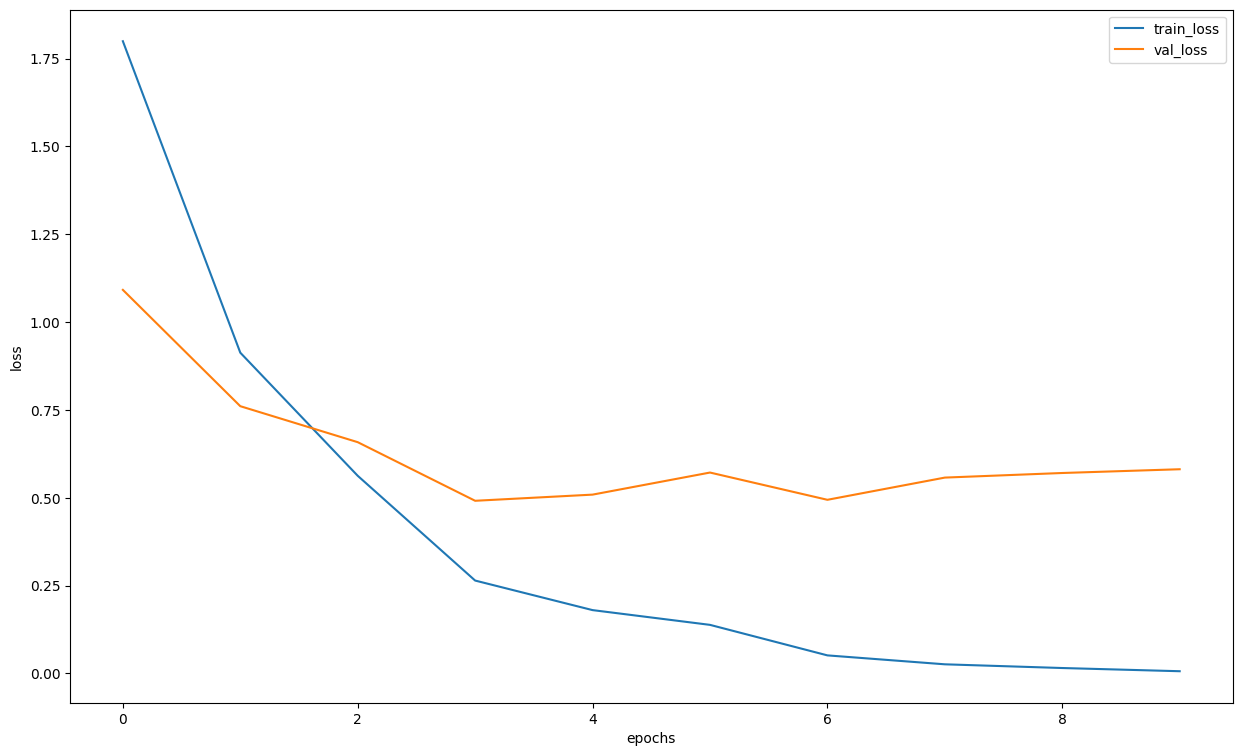

In [34]:
loss, acc, val_loss, val_acc = zip(*history)
plt.figure(figsize=(15, 9))
plt.plot(loss, label="train_loss")
plt.plot(val_loss, label="val_loss")
plt.legend(loc='best')
plt.xlabel("epochs")
plt.ylabel("loss")
plt.show()

### Ну и что теперь со всем этим делать?

![alt text](https://www.indiewire.com/wp-content/uploads/2014/08/the-simpsons.jpg)

Хорошо бы понять, как сделать сабмит.
У нас есть сеть и методы eval у нее, которые позволяют перевести сеть в режим предсказания. Стоит понимать, что у нашей модели на последнем слое стоит `softmax`, которые позволяет получить вектор вероятностей  того, что объект относится к тому или иному классу. Давайте воспользуемся этим.

In [35]:
def predict_one_sample(model, inputs, device=DEVICE):
    """Предсказание, для одной картинки"""
    with torch.no_grad():
        inputs = inputs.to(device)
        model.eval()
        logit = model(inputs).to(device)
        probs = torch.nn.functional.softmax(logit, dim=-1).cpu().numpy()
    return probs

In [36]:
label_encoder = pickle.load(open("label_encoder.pkl", 'rb'))

def count_f1(model):
    random_characters = int(np.random.uniform(0,1000))
    ex_img, true_label = val_dataset[random_characters]
    probs_im = predict_one_sample(model, ex_img.unsqueeze(0))

    idxs = list(map(int, np.random.uniform(0,1000, 20)))
    imgs = [val_dataset[id][0].unsqueeze(0) for id in idxs]

    probs_ims = predict(model, imgs)

    y_pred = np.argmax(probs_ims, -1)

    actual_labels = [val_dataset[id][1] for id in idxs]

    preds_class = [label_encoder.classes_[i] for i in y_pred]

    return actual_labels, y_pred

Обратите внимание, что метрика, которую необходимо оптимизировать в конкурсе -- `f1-score`.

Вычислим целевую метрику на валидационной выборке.

In [37]:
from sklearn.metrics import f1_score

actual_labels, y_pred = count_f1(model=simple_cnn)
f1 = f1_score(actual_labels, y_pred, average='micro')

print("F1-оценка:", f1)

F1-оценка: 0.9


Сделаем классную визуализацию,  чтобы посмотреть насколько сеть уверена в своих ответах. Можете исспользовать это, чтобы отлаживать правильность вывода.

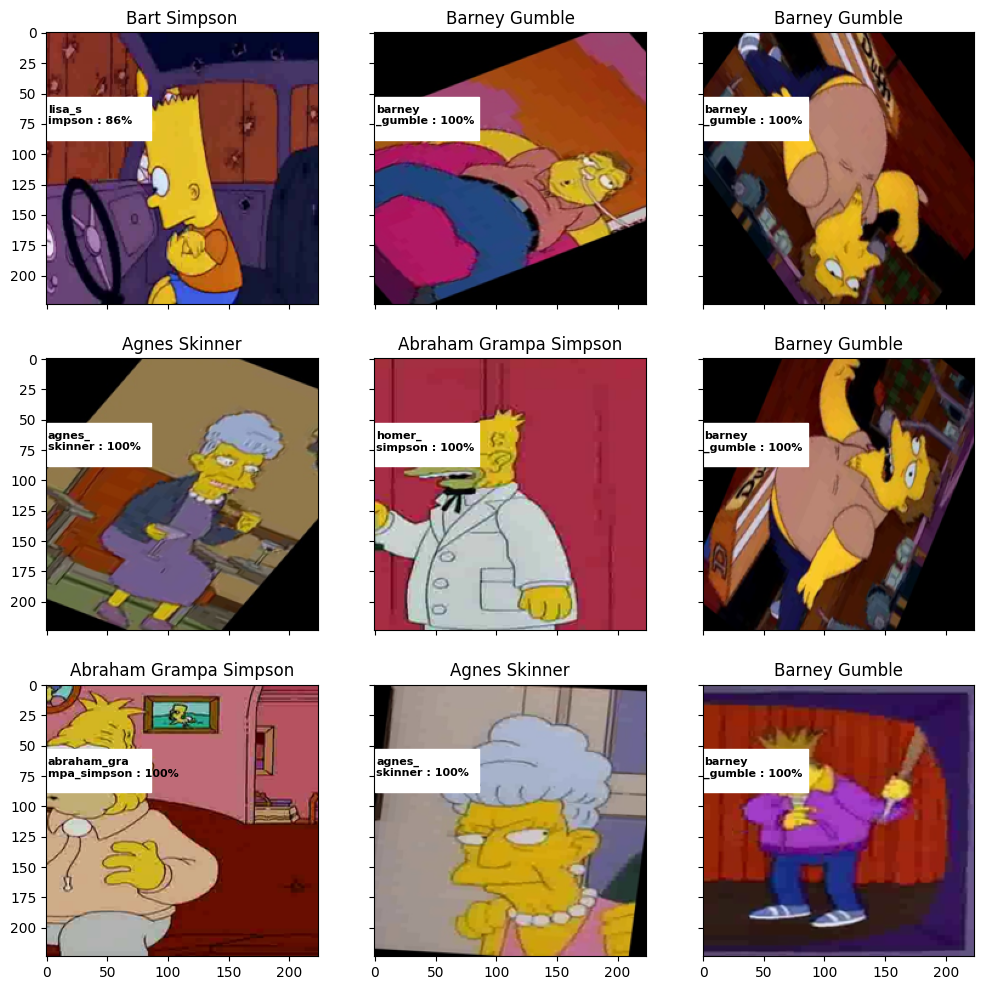

In [38]:
import matplotlib.patches as patches
from matplotlib.font_manager import FontProperties

fig, ax = plt.subplots(nrows=3, ncols=3,figsize=(12, 12), \
                        sharey=True, sharex=True)
for fig_x in ax.flatten():
    random_characters = int(np.random.uniform(0,1000))
    im_val, label = val_dataset[random_characters]
    img_label = " ".join(map(lambda x: x.capitalize(),\
                val_dataset.label_encoder.inverse_transform([label])[0].split('_')))



    imshow(im_val.data.cpu(), \
          title=img_label,plt_ax=fig_x)

    actual_text = "Actual : {}".format(img_label)

    fig_x.add_patch(patches.Rectangle((0, 53),86,35,color='white'))
    font0 = FontProperties()
    font = font0.copy()
    font.set_family("fantasy")
    prob_pred = predict_one_sample(simple_cnn, im_val.unsqueeze(0))
    predicted_proba = np.max(prob_pred)*100
    y_pred = np.argmax(prob_pred)

    predicted_label = label_encoder.classes_[y_pred]
    predicted_label = predicted_label[:len(predicted_label)//2] + '\n' + predicted_label[len(predicted_label)//2:]
    predicted_text = "{} : {:.0f}%".format(predicted_label,predicted_proba)

    fig_x.text(1, 59, predicted_text , horizontalalignment='left', fontproperties=font,
                    verticalalignment='top',fontsize=8, color='black',fontweight='bold')

### Submit на Kaggle

![alt text](https://i.redd.it/nuaphfioz0211.jpg)

In [39]:
test_dataset = SimpsonsDataset(test_files, mode="test")
test_loader = DataLoader(test_dataset, shuffle=False, batch_size=64)
test_filenames = [path.name for path in test_dataset.files]

def do_preds(model):
    probs = predict(model, test_loader)
    preds = label_encoder.inverse_transform(np.argmax(probs, axis=1))
    return preds

In [48]:
import pandas as pd

my_submit = pd.DataFrame(columns=['Id'])
my_submit['Id'] = test_filenames

preds = do_preds(simple_cnn)
my_submit[f'Expected'] = preds

my_submit.to_csv('my_cnn.csv', index=False)
my_submit.head()

,Id,Expected
0,img0.jpg,nelson_muntz
1,img1.jpg,bart_simpson
2,img10.jpg,ned_flanders
3,img100.jpg,chief_wiggum
4,img101.jpg,apu_nahasapeemapetilon


## Приключение?

А теперь самое интересное, мы сделали простенькую сверточную сеть и смогли отправить сабмит, но получившийся скор нас явно не устраивает. Надо с этим что-то сделать.

Несколько срочных улучшений для нашей сети, которые наверняка пришли Вам в голову:
1. Работа с датасетом:
* проверка (EDA) и предобработка;
* дополнение, выравниванике кол-ва картинок в классах - изменять можно как сами картинки, формируя новый датасет, или в класссе SimpsonsDataset;
* с помощью [аугментации](https://habr.com/ru/companies/smartengines/articles/264677/) или [без](https://www.geeksforgeeks.org/python-data-augmentation/);

2. Рабта с архитектурой сети:
* учим дольше и изменяем (подбираем) гиперпараметры: learning rate, batch size, нормализация картинки и вот это всё;
* добавление/удаление свёрточных слоёв;
* кто же так строит нейронные сети? А где пулинги и батч нормы? Надо добавлять!

3. Улучшение оптимизации:
* ну разве Адам наше все? [adamW](https://www.fast.ai/2018/07/02/adam-weight-decay/) для практика, [статейка для любителей](https://openreview.net/pdf?id=ryQu7f-RZ) (очень хороший анализ), [наши ](https://github.com/MichaelKonobeev/adashift/) эксперименты для заинтересованных.

4. Файнтютинг и трансферлёнинг:
* ну разве это deep learning? Вот ResNet и Inception, которые можно зафайнтьюнить под наши данные, вот это я понимаю (можно и обучить в колабе, а можно и [готовые](https://github.com/Cadene/pretrained-models.pytorch) скачать).

5. Стоит подумать об ансамблях


Надеюсь, что у Вас получится!

![alt text](https://pbs.twimg.com/profile_images/798904974986113024/adcQiVdV.jpg)


# Fine-tuning resnet18

In [41]:
import torchvision.models as models

model_ResNet = models.resnet18(pretrained=True)

for param in model_ResNet.parameters():
    param.requires_grad = False

for param in model_ResNet.layer4.parameters(): # будем обучать параметры последнего сверточного слоя
    param .requires_grad = True

model_ResNet.fc = nn.Linear(model_ResNet.fc.in_features, n_classes)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 131MB/s]


In [42]:
history = train(train_dataset, val_dataset, model=model_ResNet.to(DEVICE), epochs=10, batch_size=64)

epoch:   0%|          | 0/10 [00:00<?, ?it/s]

loss 0.44670971809327087


epoch:  10%|█         | 1/10 [04:40<42:02, 280.28s/it]


Epoch 001 train_loss: 0.4467     val_loss 0.1866 train_acc 0.8868 val_acc 0.9506
loss 0.3017164013857308


epoch:  20%|██        | 2/10 [09:18<37:10, 278.84s/it]

...


Epoch 008 train_loss: 0.0004     val_loss 0.1209 train_acc 0.9999 val_acc 0.9780
loss 0.00018750389108969346


epoch:  90%|█████████ | 9/10 [40:41<04:29, 269.67s/it]


Epoch 009 train_loss: 0.0002     val_loss 0.1234 train_acc 0.9999 val_acc 0.9794
loss 0.0001303216566597263


epoch: 100%|██████████| 10/10 [45:11<00:00, 271.19s/it]


Epoch 010 train_loss: 0.0001     val_loss 0.1251 train_acc 0.9999 val_acc 0.9794


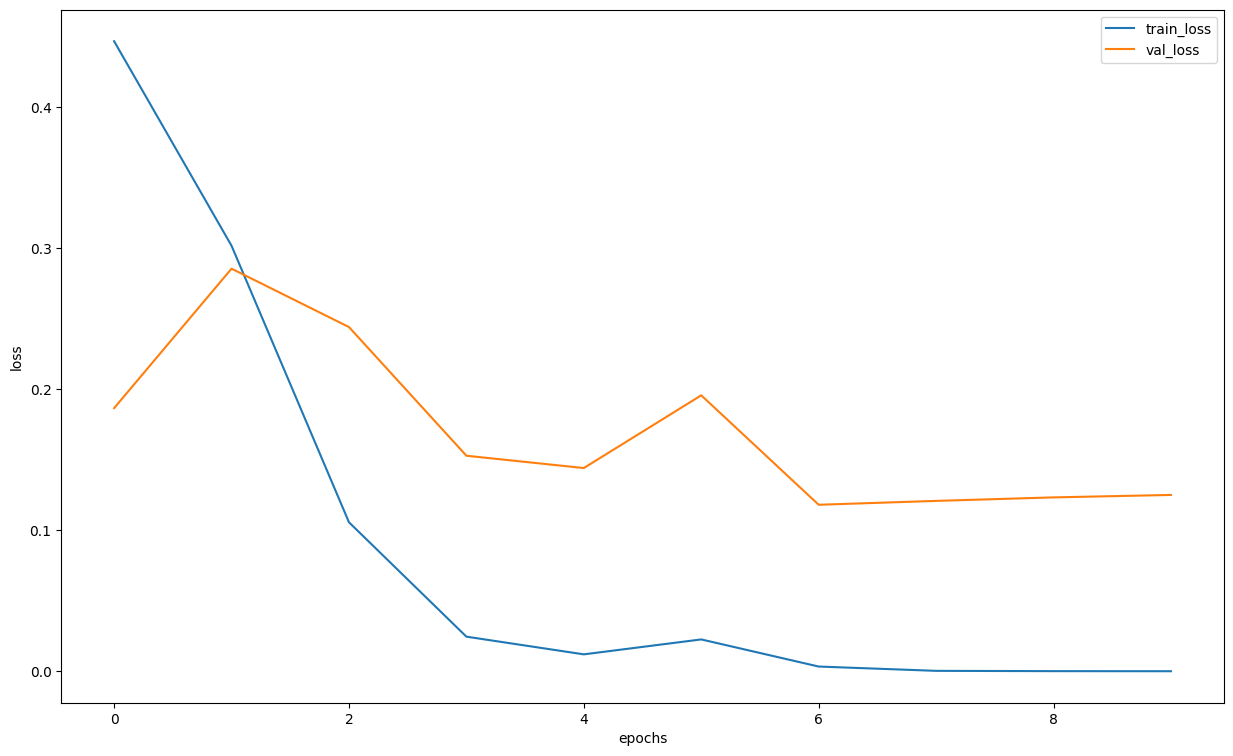

In [43]:
loss, acc, val_loss, val_acc = zip(*history)
plt.figure(figsize=(15, 9))
plt.plot(loss, label="train_loss")
plt.plot(val_loss, label="val_loss")
plt.legend(loc='best')
plt.xlabel("epochs")
plt.ylabel("loss")
plt.show()

In [44]:
actual_labels, y_pred = count_f1(model=model_ResNet)
f1 = f1_score(actual_labels, y_pred, average='micro')

print("F1-оценка:", f1)

F1-оценка: 1.0


In [49]:
preds = do_preds(model_ResNet)
my_submit[f'Expected'] = preds

my_submit.to_csv('model_ResNet.csv', index=False)
my_submit.head()

,Id,Expected
0,img0.jpg,nelson_muntz
1,img1.jpg,bart_simpson
2,img10.jpg,ned_flanders
3,img100.jpg,chief_wiggum
4,img101.jpg,apu_nahasapeemapetilon


nickname на kaggle: vadimtemplar

в таблице рейтинга: Вадим_Пяточкин_296099241